# 🩺 Exploratory Data Analysis (EDA) - Symptom-Disease Dataset

## Introduction
This dataset contains records of diseases and their associated symptoms.  
Each row represents one disease with multiple symptoms listed across columns.  

The goal of this EDA is to:
- Understand the structure of the dataset  
- Analyze missing values  
- Explore disease distribution  
- Identify the most frequent symptoms  
- Visualize relationships between diseases and symptoms


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

In [3]:
# 📌 3. Load Dataset
df = pd.read_csv("../backend/Training/data/dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4920, 18)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Information
We will check:
- Column types  
- Missing values  
- Overall dataset structure

In [4]:
# Dataset info
df.info()

# Missing values count
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   4920 non-null   object
 1   Unnamed: 1   4920 non-null   object
 2   Unnamed: 2   4920 non-null   object
 3   Unnamed: 3   4920 non-null   object
 4   Unnamed: 4   4572 non-null   object
 5   Unnamed: 5   3714 non-null   object
 6   Unnamed: 6   2934 non-null   object
 7   Unnamed: 7   2268 non-null   object
 8   Unnamed: 8   1944 non-null   object
 9   Unnamed: 9   1692 non-null   object
 10  Unnamed: 10  1512 non-null   object
 11  Unnamed: 11  1194 non-null   object
 12  Unnamed: 12  744 non-null    object
 13  Unnamed: 13  504 non-null    object
 14  Unnamed: 14  306 non-null    object
 15  Unnamed: 15  240 non-null    object
 16  Unnamed: 16  192 non-null    object
 17  Unnamed: 17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


Unnamed: 17    4848
Unnamed: 16    4728
Unnamed: 15    4680
Unnamed: 14    4614
Unnamed: 13    4416
Unnamed: 12    4176
Unnamed: 11    3726
Unnamed: 10    3408
Unnamed: 9     3228
Unnamed: 8     2976
Unnamed: 7     2652
Unnamed: 6     1986
Unnamed: 5     1206
Unnamed: 4      348
dtype: int64

## Data Cleaning
- Rename columns: First column = "Disease", rest = "Symptom_1 ... Symptom_n"  
- Handle missing values (replace with None for clarity)  

In [5]:
# Rename columns
df.columns = ["Disease"] + [f"Symptom_{i}" for i in range(1, df.shape[1])]

# Replace NaN with None for easier processing
df = df.replace(np.nan, None)

df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,Fungal infection,itching,skin_rash,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,None,None,None,None,None,None,None,None,None,None,None,None,None,None


## Target Variable (Disease) Distribution
We analyze how many records exist for each disease.

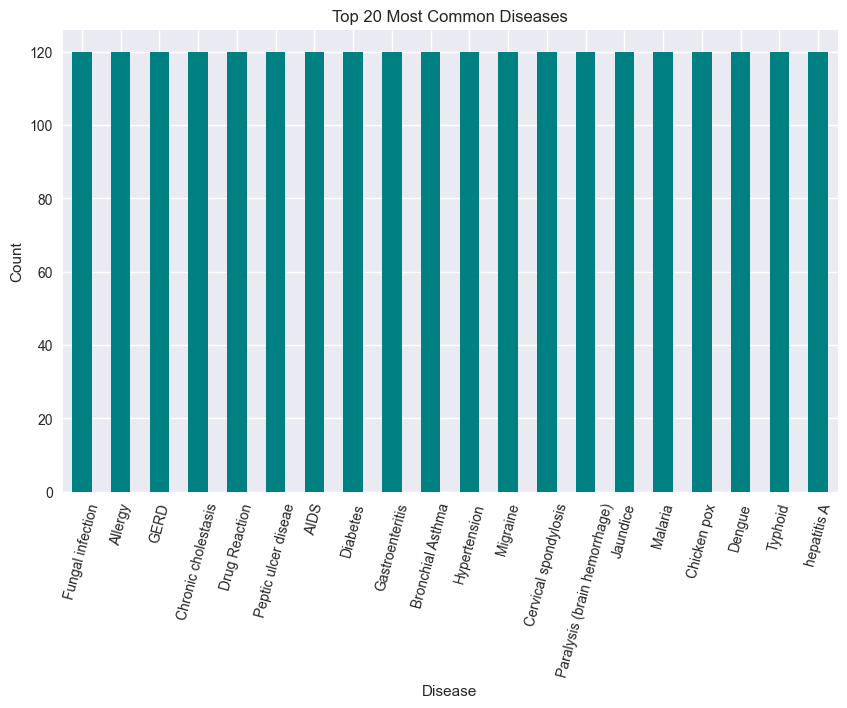

In [6]:
plt.figure(figsize=(10,6))
df["Disease"].value_counts().head(20).plot(kind="bar", color="teal")
plt.title("Top 20 Most Common Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

## Symptom Analysis
We will:
- Flatten all symptom columns into a single list  
- Count the frequency of each symptom  


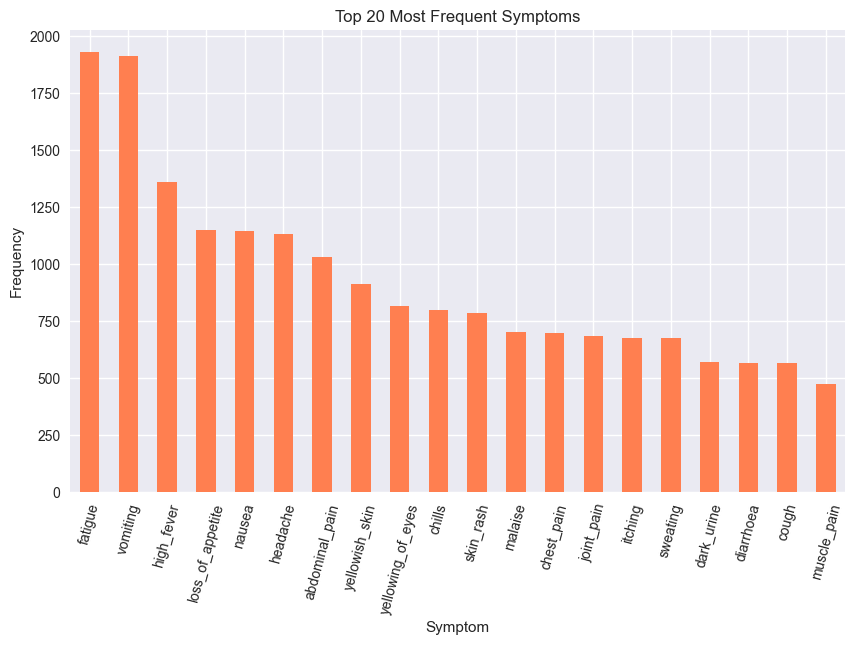

In [7]:
# Flatten symptoms
all_symptoms = df.drop("Disease", axis=1).values.ravel()
all_symptoms = pd.Series([s for s in all_symptoms if s is not None])

# Count frequency
symptom_counts = all_symptoms.value_counts()

plt.figure(figsize=(10,6))
symptom_counts.head(20).plot(kind="bar", color="coral")
plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Symptom")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.show()

## Key Insights
- Number of unique diseases and symptoms  
- Most common diseases in dataset  
- Most frequent symptoms  
- Symptom-disease relationships shown via heatmap  

In [8]:
print("Unique Diseases:", df["Disease"].nunique())
print("Unique Symptoms:", len(symptom_counts))
print("\nMost Common Disease:", df["Disease"].value_counts().idxmax())
print("Most Common Symptom:", symptom_counts.idxmax())

Unique Diseases: 41
Unique Symptoms: 131

Most Common Disease: Fungal infection
Most Common Symptom: fatigue


## Symptom-Disease Heatmap
We create a binary matrix (Disease vs Symptom) to visualize associations.

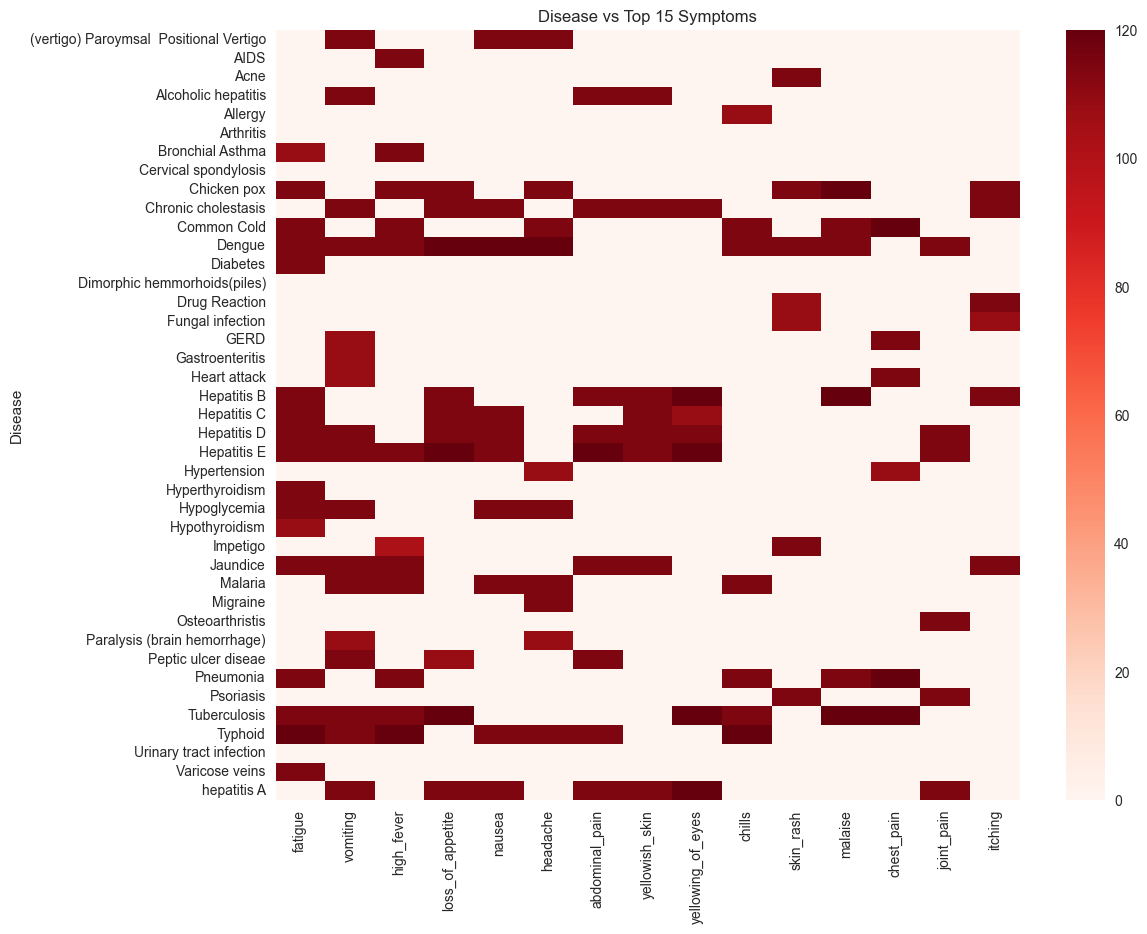

In [9]:
# Create binary symptom matrix
from sklearn.preprocessing import MultiLabelBinarizer

# Convert each row's symptoms into a list
symptom_lists = df.drop("Disease", axis=1).apply(lambda x: [s for s in x if s is not None], axis=1)

mlb = MultiLabelBinarizer()
symptom_matrix = pd.DataFrame(mlb.fit_transform(symptom_lists), columns=mlb.classes_)
symptom_matrix["Disease"] = df["Disease"]

# Heatmap for top 15 symptoms
plt.figure(figsize=(12,10))
top_symptoms = symptom_counts.head(15).index
heatmap_data = symptom_matrix.groupby("Disease")[top_symptoms].sum()

sns.heatmap(heatmap_data, cmap="Reds", cbar=True)
plt.title("Disease vs Top 15 Symptoms")
plt.show()


# 🩺 Symptom → Disease Classification Notebook
## Overview
 1. Data Loading & Cleaning
 2. Exploratory Data Analysis (EDA)
 3. Feature Engineering
 4. Train / Validation Split
 5. Baseline Models
 6. Advanced Models (RF, XGB, DT, SVM, Linear Regression)
 7. Hyperparameter Tuning
 8. Model Evaluation
 9. Feature Importance
 10. Save & Inference

In [10]:
# Imports & Settings
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib
import os

In [11]:
# Plot style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10,6)

print("Raw shape:", df.shape)
df.head()

Raw shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,Fungal infection,itching,skin_rash,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [12]:
# Cleaning & Columns
df.columns = ["Disease"] + [f"Symptom_{i}" for i in range(1, df.shape[1])]
df = df.replace({np.nan: None})

print("Cleaned shape:", df.shape)
print("Unique diseases:", df["Disease"].nunique())

Cleaned shape: (4920, 18)
Unique diseases: 41


# EDA - Disease Distribution, Symptom Frequency

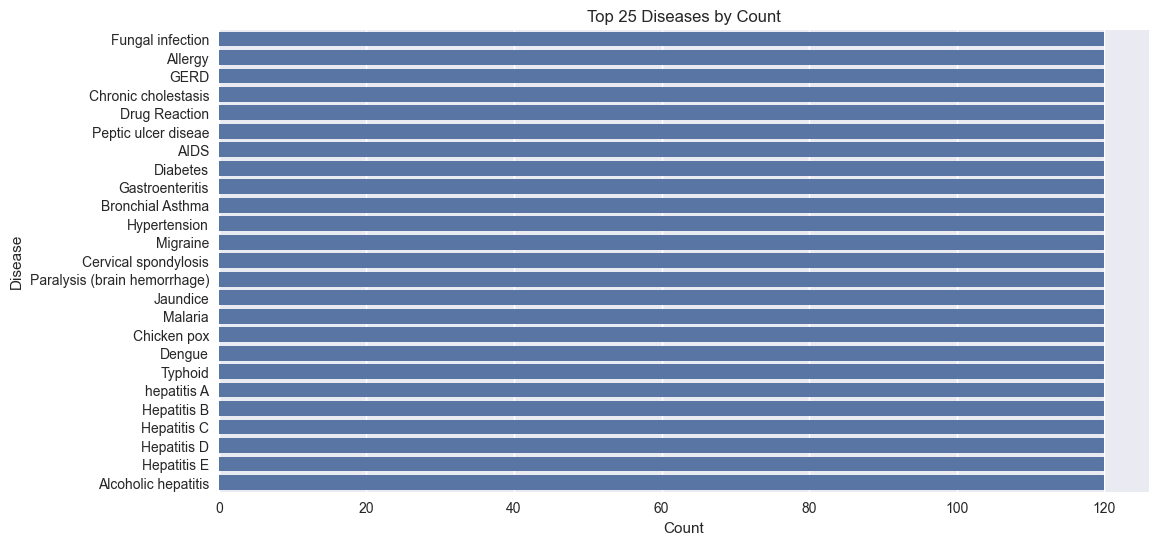

In [13]:
# Disease Distribution
top_diseases = df["Disease"].value_counts().head(25)
plt.figure(figsize=(12,6))
sns.barplot(x=top_diseases.values, y=top_diseases.index)
plt.title("Top 25 Diseases by Count")
plt.xlabel("Count")
plt.show()

Unique symptoms: 131


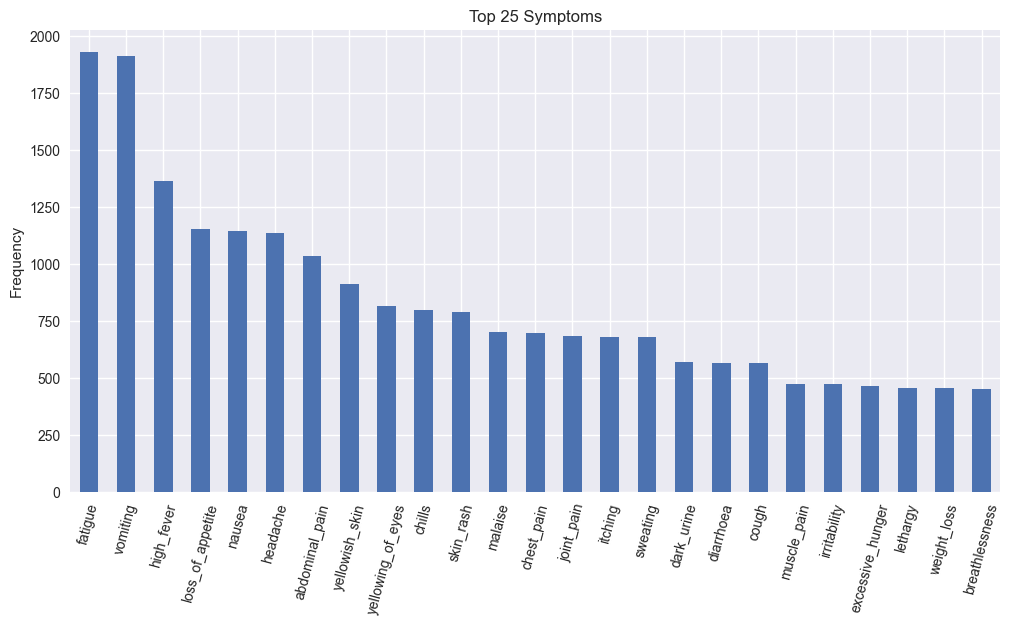

In [14]:
# Symptom Frequency
symptom_cols = [c for c in df.columns if c.startswith("Symptom_")]
all_symptoms = df[symptom_cols].values.ravel()
all_symptoms = pd.Series([s for s in all_symptoms if s is not None])
symptom_counts = all_symptoms.value_counts()

print("Unique symptoms:", symptom_counts.shape[0])

plt.figure(figsize=(12,6))
symptom_counts.head(25).plot(kind="bar")
plt.title("Top 25 Symptoms")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.show()



# Feature Engineering

In [15]:
symptom_lists = df[symptom_cols].apply(lambda row: [s for s in row if s is not None], axis=1)

mlb = MultiLabelBinarizer()
X = pd.DataFrame(mlb.fit_transform(symptom_lists), columns=mlb.classes_)

le = LabelEncoder()
y = le.fit_transform(df["Disease"])

print("X shape:", X.shape, "y shape:", y.shape, "Classes:", len(le.classes_))



X shape: (4920, 131) y shape: (4920,) Classes: 41


# Train-Test Split

In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3936, 131) Test: (984, 131)


# Model Training & Evaluation

In [17]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, solver="saga", multi_class="multinomial", n_jobs=-1, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LogReg Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print("LogReg F1:", f1_score(y_test, y_pred_lr, average="macro"))


# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print("RF F1:", f1_score(y_test, y_pred_rf, average="macro"))


# Decision Tree
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print("DT F1:", f1_score(y_test, y_pred_dt, average="macro"))


# SVM
svm = SVC(kernel="linear", probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print("SVM F1:", f1_score(y_test, y_pred_svm, average="macro"))


# XGBoost 
xgb = XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("XGB F1:", f1_score(y_test, y_pred_xgb, average="macro"))
print("\n")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("LR CV acc:", cross_val_score(lr, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean())
print("RF CV acc:", cross_val_score(rf, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean())
print("DT CV acc:", cross_val_score(dt, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean())
print("SVM CV acc:", cross_val_score(svm, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean())

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg Accuracy: 1.0
[[24  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 24  0  0]
 [ 0  0  0 ...  0 24  0]
 [ 0  0  0 ...  0  0 24]]
LogReg F1: 1.0
RF Accuracy: 1.0
[[24  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 24  0  0]
 [ 0  0  0 ...  0 24  0]
 [ 0  0  0 ...  0  0 24]]
RF F1: 1.0
DT Accuracy: 1.0
[[24  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 24  0  0]
 [ 0  0  0 ...  0 24  0]
 [ 0  0  0 ...  0  0 24]]
DT F1: 1.0
SVM Accuracy: 1.0
[[24  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 24  0  0]
 [ 0  0  0 ...  0 24  0]
 [ 0  0  0 ...  0  0 24]]
SVM F1: 1.0
XGB Accuracy: 1.0
[[24  0  0 ...  0  0  0]
 [ 0 24  0 ...  0  0  0]
 [ 0  0 24 ...  0  0  0]
 ...
 [ 0  0  0 ... 24  0  0]
 [ 0  0  0 ...  0 24  0]
 [ 0  0  0 ...  0  0 24]]
XGB F1: 1.0


LR CV acc: 1.0
RF CV acc: 1.0
DT CV acc: 1.0
SVM CV acc: 1.0


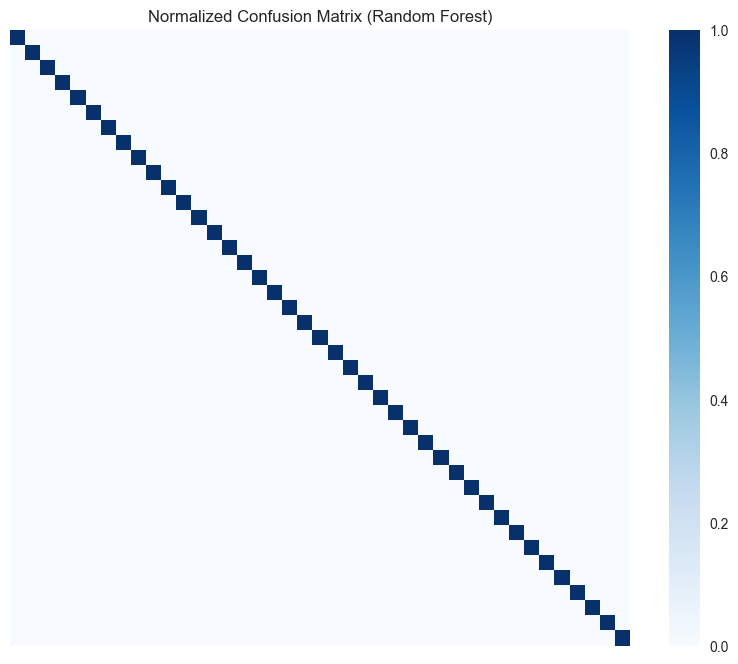

In [18]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_rf, normalize="true")
plt.figure(figsize=(10,8))
sns.heatmap(cm, xticklabels=False, yticklabels=False, cmap="Blues")
plt.title("Normalized Confusion Matrix (Random Forest)")
plt.show()

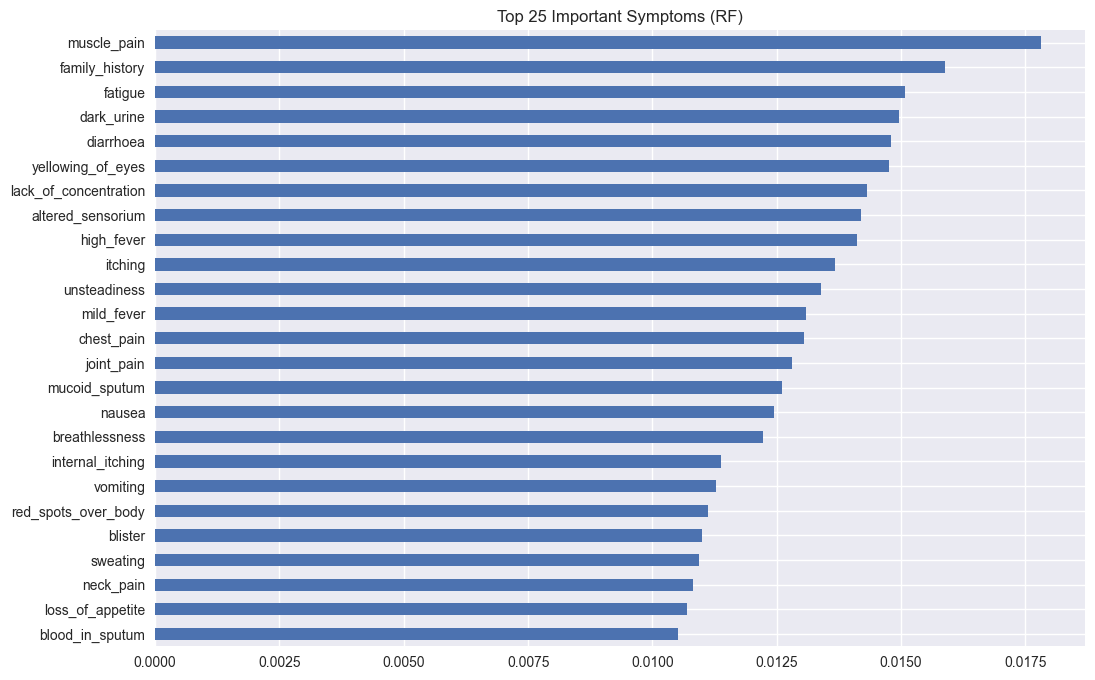

In [19]:
# Feature Importance (RF)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12,8))
feat_imp.head(25).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 25 Important Symptoms (RF)")
plt.show()

In [ ]:
# Save Final Model
final_model = rf  # choose best manually
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/final_model.joblib")
joblib.dump(mlb, "models/multi_label_binarizer.joblib")
joblib.dump(le, "models/label_encoder.joblib")
print("✅ Model + encoders saved in /models")

In [20]:
# Inference Example
def predict_disease(symptoms_list, model=final_model, mlb=mlb, le=le):
    x = mlb.transform([symptoms_list])
    pred_label = model.predict(x)[0]
    return le.inverse_transform([pred_label])[0]

sample_symptoms = ["itching", "skin_rash"]
print("Predicted disease:", predict_disease(sample_symptoms))

NameError: name 'final_model' is not defined

In [21]:
# Model Comparison
results = {}

# Store results
results["LogReg"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr, average="macro")
}
results["RandomForest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf, average="macro")
}
results["DecisionTree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "F1": f1_score(y_test, y_pred_dt, average="macro")
}
results["SVM"] = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "F1": f1_score(y_test, y_pred_svm, average="macro")
}
results["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "F1": f1_score(y_test, y_pred_xgb, average="macro")
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T.sort_values(by="Accuracy", ascending=False)

print("📊 Model Performance Comparison")
display(results_df)

📊 Model Performance Comparison


,Accuracy,F1
LogReg,1.0,1.0
RandomForest,1.0,1.0
DecisionTree,1.0,1.0
SVM,1.0,1.0
XGBoost,1.0,1.0


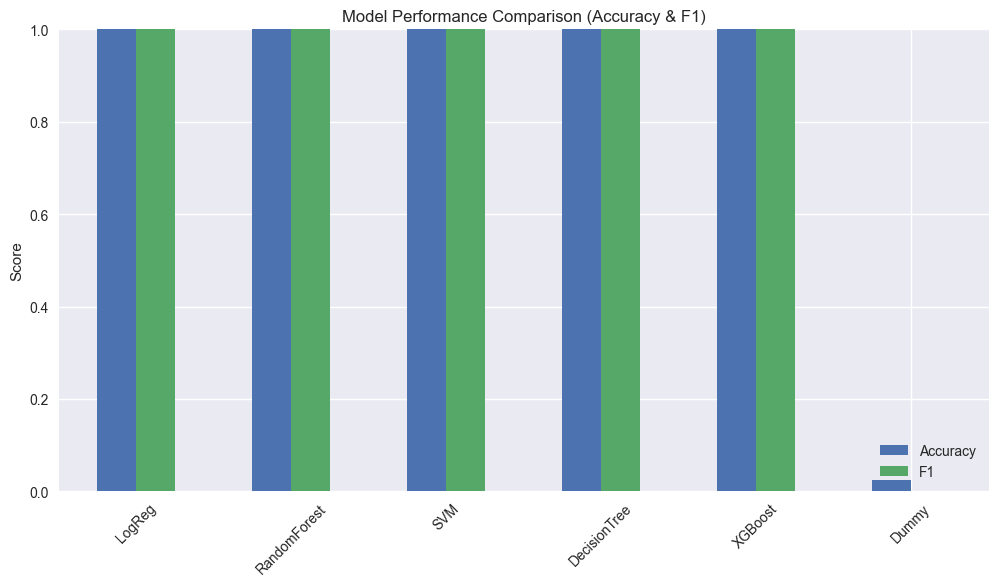

In [ ]:
# Plot Comparison
results_df.plot(kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison (Accuracy & F1)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()